In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('data/SuperMarket Analysis.csv')
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [3]:
df.isna().sum()

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

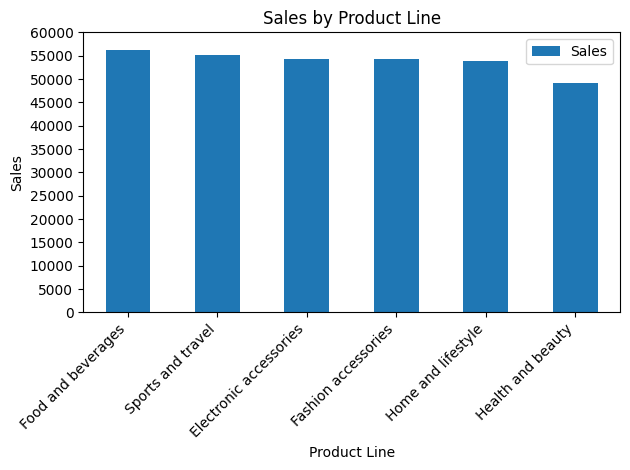

In [23]:
product_sales = df.groupby('Product line')['Sales'].sum().reset_index().sort_values(by='Sales', ascending=False)
product_sales.plot(x='Product line', y='Sales', kind='bar')
plt.xlabel('Product Line')
plt.ylabel('Sales')
plt.title('Sales by Product Line')
plt.xticks(rotation=45, ha='right')
plt.yticks(range(0, int(product_sales['Sales'].max()) + 5000, 5000))
plt.tight_layout()
plt.show()

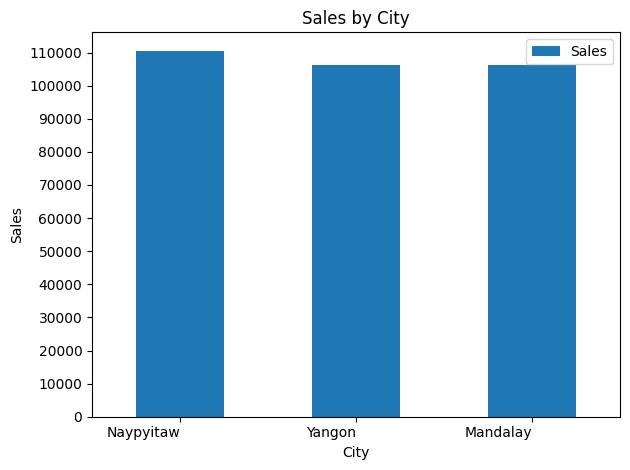

In [9]:
city_sales = df.groupby('City')['Sales'].sum().reset_index().sort_values(by='Sales', ascending=False)
city_sales.plot(x='City', y='Sales', kind='bar')
plt.xlabel('City')
plt.ylabel('Sales')
plt.title('Sales by City')
plt.xticks(rotation=0, ha='right')
plt.yticks(range(0, int(city_sales['Sales'].max()) + 5000, 10000))
plt.tight_layout()
plt.show()

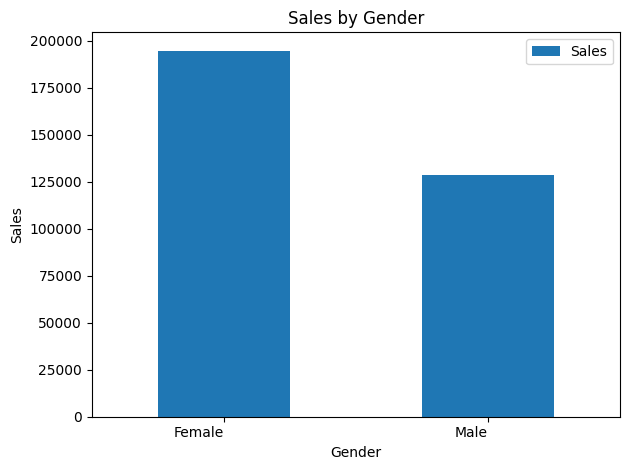

In [10]:
gender_sales = df.groupby('Gender')['Sales'].sum().reset_index().sort_values(by='Sales', ascending=False)
gender_sales.plot(x='Gender', y='Sales', kind='bar')
plt.xlabel('Gender')
plt.ylabel('Sales') 
plt.title('Sales by Gender')
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

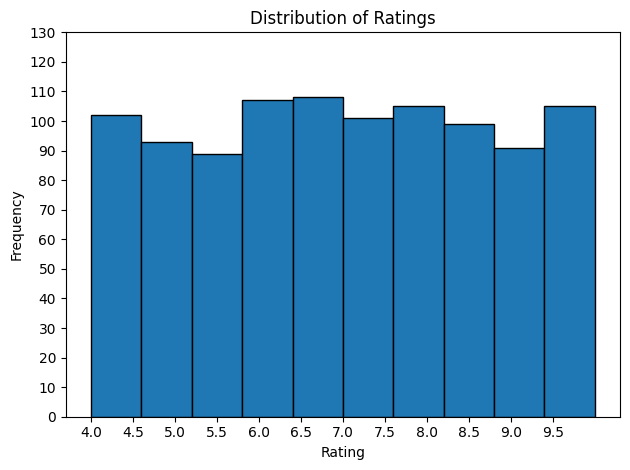

In [22]:
plt.hist(df['Rating'], bins=10, edgecolor='black')
plt.xlabel('Rating')
plt.ylabel('Frequency') 
plt.title('Distribution of Ratings')
plt.xticks(np.arange(4, max(df['Rating']), 0.5))
plt.yticks(range(0, 140, 10))
plt.tight_layout()
plt.show()

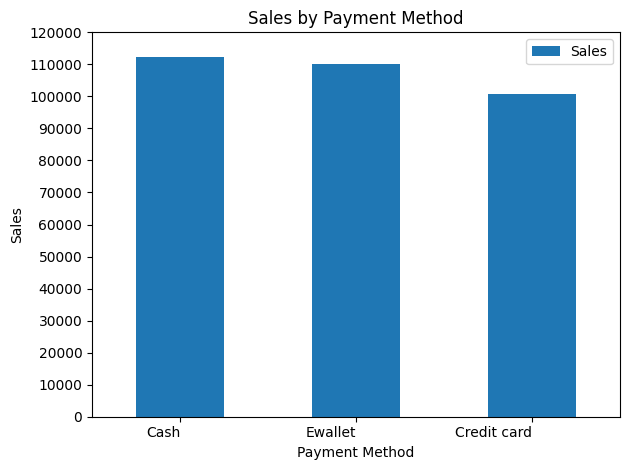

In [27]:
payment_sales = df.groupby('Payment')['Sales'].sum().reset_index().sort_values(by='Sales', ascending=False) 
payment_sales.plot(x='Payment', y='Sales', kind='bar')
plt.xlabel('Payment Method')
plt.ylabel('Sales')
plt.title('Sales by Payment Method')
plt.xticks(rotation=0, ha='right')
plt.yticks(range(0, int(payment_sales['Sales'].max()) + 10000, 10000))
plt.tight_layout()
plt.show()

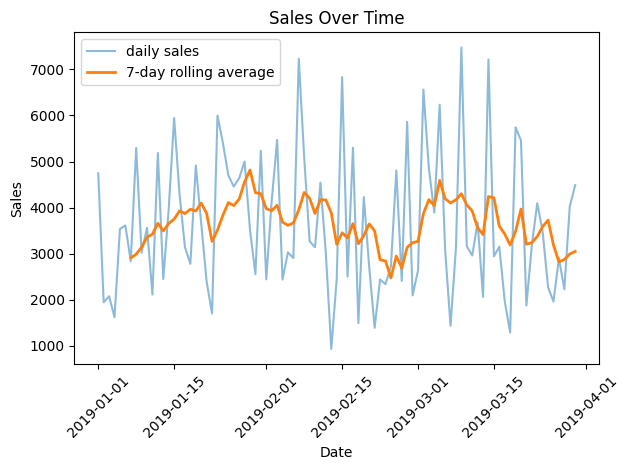

In [28]:
df['datetime'] = pd.to_datetime(df['Date'])
datetime_sales = df.groupby(df['datetime'].dt.date)['Sales'].sum().reset_index()
plt.plot(datetime_sales['datetime'], datetime_sales['Sales'], label='daily sales', alpha=0.5)
plt.plot(datetime_sales['datetime'], datetime_sales['Sales'].rolling(window=7).mean(), label='7-day rolling average', linewidth=2)
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Sales Over Time')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

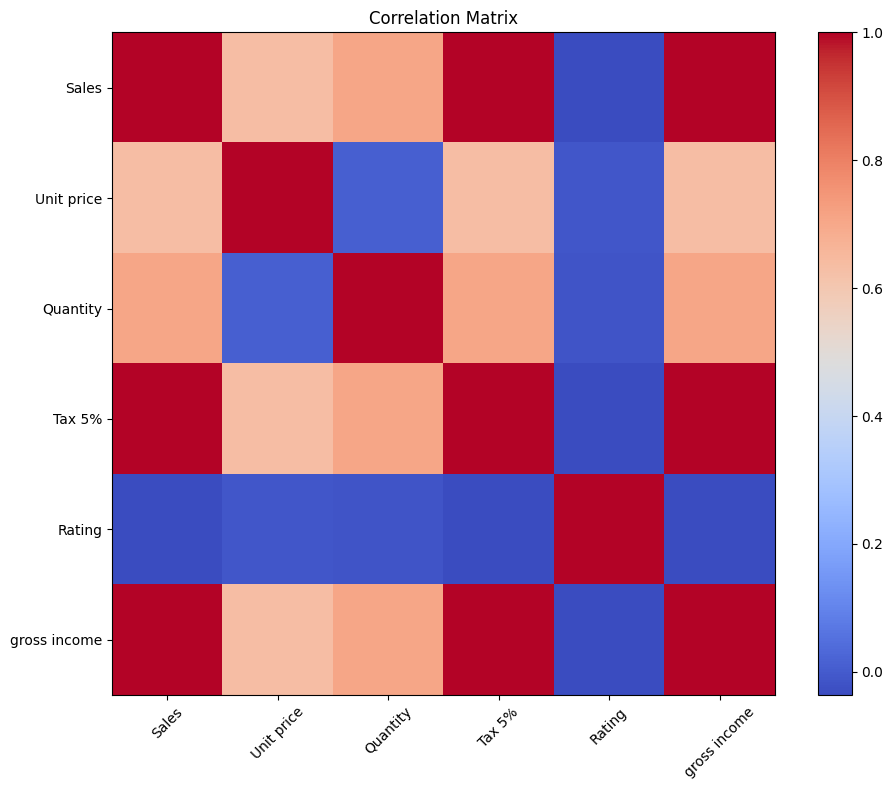

In [31]:
corr = df[['Sales', 'Unit price', 'Quantity', 'Tax 5%', 'Rating', 'gross income']].corr()
plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap='coolwarm',)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

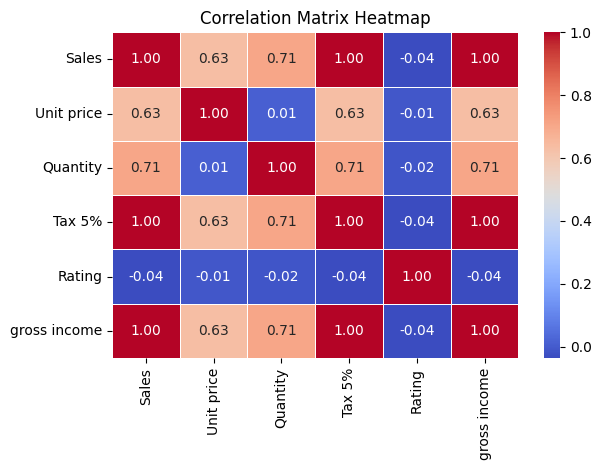

In [32]:
import seaborn as sns

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()